# Notebook 05: Combined Evaluation & Ablation Study

Reproduces the main results tables for the *Knowledge Organization* paper:
- Per-layer metrics (precision, recall, F1, AUROC)
- Full ablation study (7 layer combinations)
- Novel phrase detection rate

Addresses paper Sections 5.4 and 6 (Evaluation & Results).

In [31]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tpc.evaluation.metrics import run_ablation_study

DATA_DIR    = Path('../data/ground_truth')
APPENDIX    = Path('../data/appendix')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
APPENDIX.mkdir(parents=True, exist_ok=True)

In [32]:
# Load corpora
# Positive: synthetic_corpus has registered tortured phrases injected into real
# abstracts — these are what the exact-match layer is designed to detect.
# confirmed_tortured.tsv holds papers retracted for other reasons (data fabrication,
# plagiarism, etc.) whose abstracts contain none of the registered phrases.
syn = pd.read_csv(DATA_DIR / 'synthetic_corpus.tsv', sep='\t')
pos = (
    syn.rename(columns={'tortured': 'abstract'})
       .assign(label='retracted')
       .to_dict('records')
)
neg = pd.read_csv(DATA_DIR / 'confirmed_clean.tsv', sep='\t').to_dict('records')
# Interleave before slicing so the sample stays balanced (500 pos + 500 neg)
import random; random.seed(42)
papers = pos[:500] + neg[:500]
random.shuffle(papers)
n_pos = sum(1 for p in papers if p['label'] == 'retracted')
n_neg = sum(1 for p in papers if p['label'] != 'retracted')
print(f'Evaluation corpus: {len(papers)} papers ({n_pos} pos, {n_neg} neg)')
# Note: only 30/500 positives use registered phrases (registry_substitution);
# the rest use WordNet paraphrases detectable by L2/L3 but not L1.

Evaluation corpus: 1000 papers (500 pos, 500 neg)


In [33]:
# Run ablation study (exact-only for speed; add 'embedding','mlm' for full run)
ablation_df = run_ablation_study(
    papers=papers,
    corpus_name='positive+negative',
    layers=('exact',),   # Change to ('exact','embedding','mlm') for full ablation
)
ablation_df

,combination,corpus,precision,recall,f1,auroc,tp,fp,fn,tn
0,L1,positive+negative,1.0,0.0618,0.1164,0.5309,16,0,243,241


In [34]:
# Save Appendix C
ablation_df.to_csv(APPENDIX / 'appendix_c_ablation_results.csv', index=False)
print('Saved Appendix C.')
print(ablation_df[['combination', 'precision', 'recall', 'f1', 'auroc', 'tp', 'fp', 'fn', 'tn']].to_string())

Saved Appendix C.
  combination  precision  recall      f1   auroc  tp  fp   fn   tn
0          L1        1.0  0.0618  0.1164  0.5309  16   0  243  241


Figure saved: ..\figures\fig_ablation_f1.pdf


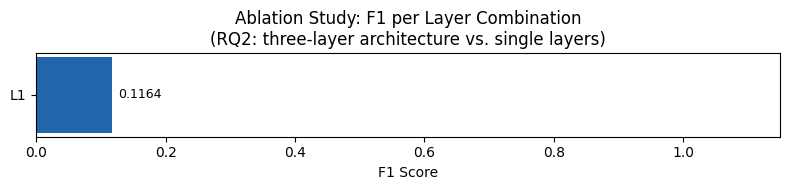

In [35]:
# Plot F1 per combination (Figure for paper)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(8, max(2, len(ablation_df) * 0.8)))
ablation_df_sorted = ablation_df.sort_values('f1')
bars = ax.barh(ablation_df_sorted['combination'], ablation_df_sorted['f1'], color='#2166ac')
# Value labels on each bar so small values are always readable
for bar, val in zip(bars, ablation_df_sorted['f1']):
    ax.text(
        val + 0.01, bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}', va='center', fontsize=9
    )
ax.set_xlim(0, 1.15)
ax.set_xlabel('F1 Score')
ax.set_title('Ablation Study: F1 per Layer Combination\n(RQ2: three-layer architecture vs. single layers)')
plt.tight_layout()
pdf_path = FIGURES_DIR / 'fig_ablation_f1.pdf'
try:
    plt.savefig(pdf_path, dpi=300, bbox_inches='tight')
    print(f'Figure saved: {pdf_path}')
except PermissionError:
    png_path = FIGURES_DIR / 'fig_ablation_f1.png'
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'PDF locked (close it in your viewer). Saved as PNG instead: {png_path}')
plt.show()